# Centralized ProtoPNet Training

Full centralized training of ProtoPNet on PCOS ultrasound data.
- Frozen USFM ViT-Base backbone + LoRA adapters + prototype layer
- All ProtoPNet losses (cls + cluster + separation) + prototype projection
- Trains on all 3 sites pooled (centralized upper bound)

In [1]:
# ============================================================
# Cell 1: Install dependencies
# ============================================================
!pip install -q timm imagehash openpyxl scikit-learn gdown

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 15.6 GB


In [2]:
# ============================================================
# Cell 2: Download datasets and USFM weights
# ============================================================
import os, subprocess, json

os.makedirs('/kaggle/working/data/raw', exist_ok=True)
os.makedirs('/kaggle/working/weights', exist_ok=True)
os.makedirs('/kaggle/working/data/processed', exist_ok=True)

DATA = '/kaggle/working/data/raw'
WTS = '/kaggle/working/weights'

# --- Download PCOSGen-train ---
if not os.path.exists(f'{DATA}/pcosgen_train/PCOSGen-train/images'):
    print('Downloading PCOSGen-train...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/PCOSGen-train.zip',
                    'https://zenodo.org/api/records/10430727/files/PCOSGen-train.zip/content'], check=True)
    subprocess.run(['unzip', '-q', f'{DATA}/PCOSGen-train.zip', '-d', f'{DATA}/pcosgen_train'], check=True)
    os.remove(f'{DATA}/PCOSGen-train.zip')
    print(f'  Done: {len(os.listdir(f"{DATA}/pcosgen_train/PCOSGen-train/images"))} images')

# --- Download PCOSGen-test ---
if not os.path.exists(f'{DATA}/pcosgen_test/images'):
    print('Downloading PCOSGen-test...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/PCOSGen-test.zip',
                    'https://zenodo.org/api/records/10960327/files/PCOSGen-test.zip/content'], check=True)
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/PCOSGen-test_labels.csv',
                    'https://zenodo.org/api/records/10960327/files/class%20label.csv/content'], check=True)
    subprocess.run(['unzip', '-q', f'{DATA}/PCOSGen-test.zip', '-d', f'{DATA}/pcosgen_test'], check=True)
    os.remove(f'{DATA}/PCOSGen-test.zip')
    print(f'  Done: {len(os.listdir(f"{DATA}/pcosgen_test/images"))} images')

# --- Download Figshare (Indirani) ---
if not os.path.exists(f'{DATA}/figshare_pcos/PCOS'):
    print('Downloading Figshare PCOS dataset (390MB)...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/figshare_pcos.zip',
                    'https://ndownloader.figshare.com/files/50407062'], check=True)
    subprocess.run(['unzip', '-q', f'{DATA}/figshare_pcos.zip', '-d', f'{DATA}/figshare_pcos'], check=True)
    os.remove(f'{DATA}/figshare_pcos.zip')
    print(f'  Done: infected={len(os.listdir(f"{DATA}/figshare_pcos/PCOS/infected"))}, '
          f'noninfected={len(os.listdir(f"{DATA}/figshare_pcos/PCOS/noninfected"))}')

# --- Download HananSaadat ---
if not os.path.exists(f'{DATA}/hanan/PCO'):
    print('Downloading HananSaadat dataset...')
    subprocess.run(['curl', '-sL', '-o', f'{DATA}/hanan.rar',
                    'https://github.com/HananSaadat/ovarian_ultrasound_dataset/raw/main/ovarian_ultrasound_dataset.rar'], check=True)
    subprocess.run(['unrar', 'x', '-y', f'{DATA}/hanan.rar', f'{DATA}/hanan/'], check=True)
    os.remove(f'{DATA}/hanan.rar')
    print(f'  Done: PCO={len(os.listdir(f"{DATA}/hanan/PCO"))}, '
          f'Normal={len(os.listdir(f"{DATA}/hanan/Normal"))}, '
          f'Dominant={len(os.listdir(f"{DATA}/hanan/Dominant_Follicle"))}')

# --- Download USFM weights ---
if not os.path.exists(f'{WTS}/USFM_latest.pth'):
    print('Downloading USFM weights (343MB)...')
    import gdown
    gdown.download(id='1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q',
                   output=f'{WTS}/USFM_latest.pth', quiet=False)
    print(f'  Done: {os.path.getsize(f"{WTS}/USFM_latest.pth") / 1e6:.1f} MB')

# --- Clone USFM repo ---
if not os.path.exists('/kaggle/working/USFM'):
    print('Cloning USFM repo...')
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/openmedlab/USFM.git', '/kaggle/working/USFM'], check=True)

print('\nAll downloads complete!')

  Done: 3200 images
  Done: 1468 images
  Done: infected=6784, noninfected=5000

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /kaggle/working/data/raw/hanan.rar

Creating    /kaggle/working/data/raw/hanan                            OK
Creating    /kaggle/working/data/raw/hanan/Dominant_Follicle          OK
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/desktop.ini       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_1.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_10.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_100.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_101.jpg       0%  OK 
Extracting  /kaggle/working/data/raw/hanan/Dominant_Follicle/Dominant_Follicle_102.jpg       1%  OK 
Ext

Downloading...
From (original): https://drive.google.com/uc?id=1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q
From (redirected): https://drive.google.com/uc?id=1KRwXZgYterH895Z8EpXpR1L1eSMMJo4q&confirm=t&uuid=00aae2d0-74fa-4d7b-a848-584a30fe9dbf
To: /kaggle/working/weights/USFM_latest.pth
100%|██████████| 343M/343M [00:04<00:00, 73.8MB/s]
Cloning into '/kaggle/working/USFM'...


  Done: 343.0 MB
Cloning USFM repo...

All downloads complete!


In [3]:
# ============================================================
# Cell 3: Deduplication (same logic as sandbox)
# ============================================================
import json, hashlib, imagehash, csv, openpyxl
from collections import defaultdict
from PIL import Image
from pathlib import Path
import numpy as np

RAW = Path(DATA)
DEDUP = Path('/kaggle/working/data/dedup')
DEDUP.mkdir(parents=True, exist_ok=True)

# Check if dedup already done (from previous run)
if os.path.exists('/kaggle/working/data/processed/dataset_manifest.json'):
    print('Manifest already exists - skipping dedup')
    with open('/kaggle/working/data/processed/dataset_manifest.json') as f:
        manifest = json.load(f)
else:
    print('Running deduplication...')
    
    DATASETS = {
        'pcosgen_train': RAW / 'pcosgen_train/PCOSGen-train/images',
        'pcosgen_test': RAW / 'pcosgen_test/images',
        'hanan_normal': RAW / 'hanan/Normal',
        'hanan_dominant': RAW / 'hanan/Dominant_Follicle',
        'hanan_pco': RAW / 'hanan/PCO',
        'figshare_infected': RAW / 'figshare_pcos/PCOS/infected',
        'figshare_noninfected': RAW / 'figshare_pcos/PCOS/noninfected',
    }
    
    # Step 1: Compute hashes
    records = []
    for ds_name, img_dir in DATASETS.items():
        if not img_dir.exists(): continue
        imgs = sorted([f for f in img_dir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
        print(f'  {ds_name}: {len(imgs)} images')
        for img_path in imgs:
            try:
                img = Image.open(img_path).convert('RGB')
                ph = str(imagehash.phash(img, hash_size=16))
                ah = str(imagehash.average_hash(img, hash_size=16))
                with open(img_path, 'rb') as f:
                    md5 = hashlib.md5(f.read()).hexdigest()
                records.append({'dataset': ds_name, 'filename': img_path.name,
                                'path': str(img_path), 'phash': ph, 'ahash': ah, 'md5': md5})
            except: pass
    print(f'Total hashed: {len(records)}')
    
    # Step 2: Build duplicate graph (exact + near-dups, cross + intra)
    def hash_to_bits(h):
        v = int(h, 16)
        return np.array([(v >> i) & 1 for i in range(256)], dtype=np.uint8)
    
    adj = defaultdict(set)
    # Exact dups (md5)
    md5_groups = defaultdict(list)
    for r in records: md5_groups[r['md5']].append((r['dataset'], r['filename']))
    for md5, nodes in md5_groups.items():
        if len(nodes) > 1:
            for i in range(len(nodes)):
                for j in range(i+1, len(nodes)):
                    adj[nodes[i]].add(nodes[j]); adj[nodes[j]].add(nodes[i])
    
    # Near-dups (pHash + aHash, cross + intra)
    by_ds = defaultdict(list)
    for r in records: by_ds[r['dataset']].append(r)
    
    # Cross-dataset
    ds_names = list(by_ds.keys())
    for i in range(len(ds_names)):
        for j in range(i+1, len(ds_names)):
            a, b = by_ds[ds_names[i]], by_ds[ds_names[j]]
            ba = np.stack([hash_to_bits(r['phash']) for r in a])
            bb = np.stack([hash_to_bits(r['phash']) for r in b])
            for ci in range(len(a)):
                dists = np.sum(ba[ci][None, :] != bb, axis=1)
                for cj in np.where(dists <= 5)[0]:
                    na, nb = (a[ci]['dataset'], a[ci]['filename']), (b[cj]['dataset'], b[cj]['filename'])
                    adj[na].add(nb); adj[nb].add(na)
    
    # Intra-dataset
    for ds_name, ds_recs in by_ds.items():
        if len(ds_recs) < 2: continue
        bits = np.stack([hash_to_bits(r['phash']) for r in ds_recs])
        N = len(ds_recs)
        for ci in range(N):
            dists = np.sum(bits[ci][None, :] != bits, axis=1)
            for cj in np.where((dists <= 5) & (np.arange(N) > ci))[0]:
                na, nb = (ds_recs[ci]['dataset'], ds_recs[ci]['filename']), (ds_recs[cj]['dataset'], ds_recs[cj]['filename'])
                adj[na].add(nb); adj[nb].add(na)
    
    # Step 3: Connected components
    visited = set()
    clusters = []
    for node in list(adj.keys()):
        if node not in visited:
            cluster = set(); stack = [node]
            while stack:
                n = stack.pop()
                if n in visited: continue
                visited.add(n); cluster.add(n)
                for nb in adj[n]:
                    if nb not in visited: stack.append(nb)
            clusters.append(cluster)
    print(f'Duplicate clusters: {len(clusters)}')
    
    # Step 4: Assign representatives and build manifest
    record_map = {(r['dataset'], r['filename']): r for r in records}
    
    # Load labels
    wb = openpyxl.load_workbook(RAW / 'pcosgen_train/PCOSGen-train/class_label.xlsx')
    ws = wb.active
    pg_labels = {row[0]: int(row[1]) for row in ws.iter_rows(min_row=2, values_only=True) if row[0] and row[1] is not None}
    test_labels = {}
    with open(RAW / 'PCOSGen-test_labels.csv') as f:
        for row in csv.DictReader(f): test_labels[row['imagePath']] = int(row['Healthy'])
    
    def get_label(ds, fn):
        if ds == 'pcosgen_train':
            v = pg_labels.get(fn); return (0 if v == 1 else 1) if v is not None else None
        elif ds == 'pcosgen_test':
            v = test_labels.get(fn); return (0 if v == 1 else 1) if v is not None else None
        elif ds == 'figshare_infected': return 1
        elif ds == 'figshare_noninfected': return 0
        elif ds == 'hanan_pco': return 1
        elif ds in ('hanan_normal', 'hanan_dominant'): return 0
        return None
    
    PRIORITY = {'pcosgen_test': 0, 'pcosgen_train': 1, 'figshare_infected': 2,
                'figshare_noninfected': 3, 'hanan_pco': 4, 'hanan_normal': 5, 'hanan_dominant': 6}
    SITE_MAP = {'pcosgen_train': 'site2_pcosgen', 'figshare_infected': 'site1_figshare',
                'figshare_noninfected': 'site1_figshare', 'hanan_pco': 'site3_hanan',
                'hanan_normal': 'site3_hanan', 'hanan_dominant': 'site3_hanan'}
    
    external_test = []
    site_images = defaultdict(list)
    
    for cluster in clusters:
        nodes = sorted(cluster, key=lambda n: PRIORITY.get(n[0], 99))
        rep = nodes[0]; r = record_map.get(rep)
        if r is None: continue
        label = get_label(rep[0], rep[1])
        if label is None: continue
        if rep[0] == 'pcosgen_test':
            external_test.append({'path': r['path'], 'label': label, 'source': 'pcosgen_test'})
        else:
            site_images[rep[0]].append({'path': r['path'], 'label': label, 'source': rep[0]})
    
    for r in records:
        key = (r['dataset'], r['filename'])
        if key in visited: continue
        label = get_label(r['dataset'], r['filename'])
        if label is None: continue
        if r['dataset'] == 'pcosgen_test':
            external_test.append({'path': r['path'], 'label': label, 'source': 'pcosgen_test'})
        else:
            site_images[r['dataset']].append({'path': r['path'], 'label': label, 'source': r['dataset']})
    
    final_sites = defaultdict(list)
    for ds, imgs in site_images.items():
        final_sites[SITE_MAP.get(ds, ds)].extend(imgs)
    
    # Stratified split
    import random
    random.seed(42)
    def stratified_split(images, train_frac=0.70, val_frac=0.15, seed=42):
        rng = random.Random(seed)
        by_label = defaultdict(list)
        for img in images: by_label[img['label']].append(img)
        splits = {'train': [], 'val': [], 'test': []}
        for label, imgs in by_label.items():
            rng.shuffle(imgs); n = len(imgs)
            nt, nv = int(n * train_frac), int(n * val_frac)
            splits['train'].extend(imgs[:nt]); splits['val'].extend(imgs[nt:nt+nv]); splits['test'].extend(imgs[nt+nv:])
        for s in splits.values(): rng.shuffle(s)
        return splits
    
    manifest = {}
    for site_name in sorted(final_sites.keys()):
        manifest[site_name] = stratified_split(final_sites[site_name])
    manifest['external_test'] = {'train': [], 'val': [], 'test': external_test}
    
    with open('/kaggle/working/data/processed/dataset_manifest.json', 'w') as f:
        json.dump(manifest, f, indent=2)
    
    print('\n=== FINAL SITES ===')
    for sn in sorted(manifest.keys()):
        if sn == 'external_test':
            print(f'  {sn}: {len(manifest[sn]["test"])} test images')
        else:
            s = manifest[sn]
            pcos = sum(1 for x in s['train']+s['val']+s['test'] if x['label']==1)
            print(f'  {sn}: train={len(s["train"])}, val={len(s["val"])}, test={len(s["test"])} ({pcos} PCOS)')

Running deduplication...
  pcosgen_train: 3200 images
  pcosgen_test: 1468 images
  hanan_normal: 41 images
  hanan_dominant: 144 images
  hanan_pco: 116 images
  figshare_infected: 6784 images
  figshare_noninfected: 5000 images
Total hashed: 16753
Duplicate clusters: 3852

=== FINAL SITES ===
  external_test: 1411 test images
  site1_figshare: train=1078, val=230, test=234 (791 PCOS)
  site2_pcosgen: train=2040, val=436, test=439 (2086 PCOS)
  site3_hanan: train=209, val=44, test=46 (116 PCOS)


In [4]:
import numpy as np
# ============================================================
# Cell 4: Model definition (USFM + LoRA + ProtoPNet)
# ============================================================
import torch, torch.nn as nn, torch.nn.functional as F, types
from functools import partial
import sys, json, os, random, time, numpy as np
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix

sys.path.insert(0, '/kaggle/working/USFM')
from usdsgen.modules.backbone.vision_transformer import VisionTransformer

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ImageNet normalization constants (used to un-normalize for the foreground mask)
import scipy.ndimage as _ndi
_IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def compute_patch_mask(x, grid=14, fan_thr=0.06, erode_px=6, cover_frac=0.80,
                       low_thr=0.15, high_thr=0.82, std_thr=0.09):
    """Anatomical tissue mask over the ViT patch grid (14x14).
    x: (B,3,224,224) ImageNet-normalized batch. Returns (B, grid*grid) bool:
    True = ovarian/anatomical tissue patch, False = non-anatomical region.

    A patch is TISSUE only if ALL hold:
      (1) it lies inside the ultrasound acquisition fan, ERODED inward by
          `erode_px` px so the fan-boundary rim is excluded. The fan is the
          largest bright connected component (luminance > fan_thr), hole-filled.
          A patch counts as in-fan if >= cover_frac of its pixels are inside.
      (2) its mean luminance is in [low_thr, high_thr] -> removes residual black
          sector corners AND bright UI banners / caliper overlays.
      (3) its luminance std >= std_thr -> removes flat dead zones.
    Prevents prototypes AND the clustering loss from attaching to acquisition
    artifacts (sector margins, fan rim, banners/calipers, transducer). If an
    image yields zero tissue patches (rare tiny scans) callers fall back to all
    patches so no NaN/Inf appears. v1 used only per-patch mean/std, which let
    fan-EDGE patches (mixed black+bright => high std) pass; step (1) fixes that."""
    device = x.device
    mean = _IMNET_MEAN.to(device); std = _IMNET_STD.to(device)
    img = x * std + mean                          # un-normalize -> [0,1]
    gray = img.mean(dim=1, keepdim=True)          # (B,1,224,224) luminance
    P = img.shape[-1] // grid                     # patch size in px (16)
    patch_mean = F.avg_pool2d(gray, kernel_size=P, stride=P).flatten(1)   # (B, g*g)
    patch_sq   = F.avg_pool2d(gray ** 2, kernel_size=P, stride=P).flatten(1)
    patch_std  = (patch_sq - patch_mean ** 2).clamp_min(0).sqrt()          # (B, g*g)
    bright_ok  = (patch_mean >= low_thr) & (patch_mean <= high_thr) & (patch_std >= std_thr)
    # --- fan region (numpy per image): largest bright CC, fill holes, erode inward ---
    g_np = gray[:, 0].detach().cpu().numpy()
    B = x.shape[0]
    infan = torch.zeros((B, grid * grid), dtype=torch.bool)
    for b in range(B):
        gg = g_np[b]
        binm = gg > fan_thr
        lbl, n = _ndi.label(binm)
        if n == 0:
            continue
        sizes = _ndi.sum(np.ones_like(lbl), lbl, index=range(1, n + 1))
        big = (lbl == (int(np.argmax(sizes)) + 1))
        big = _ndi.binary_fill_holes(big)
        if erode_px > 0:
            big = _ndi.binary_erosion(big, iterations=erode_px)
        cov = big.astype(np.float32).reshape(grid, P, grid, P).mean(axis=(1, 3))  # (g,g)
        infan[b] = torch.from_numpy((cov >= cover_frac).reshape(-1))
    fg = infan.to(device) & bright_ok
    return fg

def apply_lora(backbone, rank=8):
    all_lora = []
    for block in backbone.blocks:
        attn = block.attn
        in_dim = attn.qkv.weight.shape[1]; out_dim = attn.qkv.weight.shape[0]
        lora_qkv_A = nn.Parameter(torch.zeros(rank, in_dim))
        lora_qkv_B = nn.Parameter(torch.zeros(out_dim, rank))
        lora_proj_A = nn.Parameter(torch.zeros(rank, in_dim))
        lora_proj_B = nn.Parameter(torch.zeros(in_dim, rank))
        nn.init.kaiming_uniform_(lora_qkv_A, a=5**0.5)
        nn.init.kaiming_uniform_(lora_proj_A, a=5**0.5)
        attn.lora_qkv_A = lora_qkv_A; attn.lora_qkv_B = lora_qkv_B
        attn.lora_proj_A = lora_proj_A; attn.lora_proj_B = lora_proj_B
        all_lora.extend([lora_qkv_A, lora_qkv_B, lora_proj_A, lora_proj_B])

        def make_fwd():
            def lora_fwd(self, x, rel_pos_bias=None):
                B, N, C = x.shape
                qkv_bias = None
                if self.q_bias is not None:
                    qkv_bias = torch.cat((self.q_bias, torch.zeros_like(self.v_bias, requires_grad=False), self.v_bias))
                qkv = F.linear(input=x, weight=self.qkv.weight, bias=qkv_bias)
                qkv = qkv + F.linear(F.linear(x, self.lora_qkv_A), self.lora_qkv_B)
                qkv = qkv.reshape(B, N, 3, self.num_heads, -1).permute(2, 0, 3, 1, 4)
                q, k, v = qkv[0], qkv[1], qkv[2]
                q = q * self.scale
                attn = q @ k.transpose(-2, -1)
                if self.relative_position_bias_table is not None:
                    rpb = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
                        self.window_size[0]*self.window_size[1]+1, self.window_size[0]*self.window_size[1]+1, -1)
                    attn = attn + rpb.permute(2, 0, 1).contiguous().unsqueeze(0)
                if rel_pos_bias is not None: attn = attn + rel_pos_bias
                attn = attn.softmax(dim=-1); attn = self.attn_drop(attn)
                x = (attn @ v).transpose(1, 2).reshape(B, N, -1)
                x = self.proj(x) + F.linear(F.linear(x, self.lora_proj_A), self.lora_proj_B)
                x = self.proj_drop(x)
                return x
            return lora_fwd
        attn.forward = types.MethodType(make_fwd(), attn)
    return all_lora

# --- ProtoPNet layer ---
class ProtoPNetLayer(nn.Module):
    def __init__(self, embed_dim=768, num_classes=2, proto_per_class=10):
        super().__init__()
        self.num_classes = num_classes; self.proto_per_class = proto_per_class
        self.num_prototypes = num_classes * proto_per_class; self.embed_dim = embed_dim
        self.prototypes = nn.Parameter(torch.randn(self.num_prototypes, embed_dim) * 0.01)

    def get_min_distances(self, patch_features, patch_mask=None):
        """patch_features: (B,N,D). patch_mask: (B,N) bool foreground mask or None.
        When a mask is given, background patches are excluded from the per-image
        min (set to +inf). Images with zero foreground fall back to all patches so
        no NaN/Inf can appear."""
        B, N, D = patch_features.shape
        x_norm = F.normalize(patch_features, dim=-1)
        p_norm = F.normalize(self.prototypes, dim=-1)
        dot = torch.matmul(x_norm, p_norm.t())          # (B,N,P)
        dist = 2.0 - 2.0 * dot                           # cosine distance in [0,2]
        if patch_mask is not None:
            m = patch_mask.to(dist.device).clone()
            no_fg = (m.sum(dim=1) == 0)                   # images with no tissue
            if no_fg.any(): m[no_fg] = True               # fallback: keep all patches
            neg = torch.full_like(dist, float('inf'))
            dist = torch.where(m.unsqueeze(-1), dist, neg)
        return dist.min(dim=1)[0]                         # (B,P)

    def forward(self, patch_features, patch_mask=None):
        return -self.get_min_distances(patch_features, patch_mask=patch_mask)

    def project_prototypes(self, patch_features_list, labels_list, mask_list=None):
        """Project each prototype onto its nearest FOREGROUND training patch,
        with robust farthest-point diversity (see below). If mask_list is provided,
        only tissue patches are candidates -> prototypes never land on background."""
        proto_device = self.prototypes.device
        protos_cpu = self.prototypes.detach().cpu()
        all_patches, all_labels, all_masks = [], [], []
        have_mask = mask_list is not None
        for bi, (pf, labs) in enumerate(zip(patch_features_list, labels_list)):
            pf_cpu = pf.detach().cpu()
            n_imgs, n_patches, D = pf_cpu.shape
            mk = mask_list[bi].detach().cpu() if have_mask else None
            for i in range(n_imgs):
                all_patches.append(pf_cpu[i])            # (n_patches, D)
                all_labels.append(labs[i].item())
                if have_mask: all_masks.append(mk[i])    # (n_patches,) bool
        all_patches = torch.stack(all_patches)           # (num_images, n_patches, D)
        num_images, n_patches, D = all_patches.shape
        all_labels = torch.tensor(all_labels)
        all_labels_expanded = all_labels.unsqueeze(1).expand(num_images, n_patches).reshape(-1)
        all_patches_flat = all_patches.reshape(-1, self.embed_dim)
        all_patches_norm = F.normalize(all_patches_flat, dim=-1)
        if have_mask:
            fg_flat = torch.stack(all_masks).reshape(-1).bool()   # (num_images*n_patches,)
        else:
            fg_flat = torch.ones(all_patches_norm.shape[0], dtype=torch.bool)
        # --- Robust diverse projection (foreground-only candidates) ---
        # Assign each prototype to its nearest candidate patch whose max cosine to
        # the already-assigned prototypes (same class) is < div_thresh. If none
        # passes (dominant recurring pattern), fall back to FARTHEST-POINT sampling
        # (minimize max-cosine to assigned set). Guarantees distinct, tissue-only
        # prototypes and prevents the collapse failure mode.
        div_thresh = getattr(self, 'proj_div_thresh', 0.92)
        for c in range(self.num_classes):
            sel = (all_labels_expanded == c) & fg_flat
            if sel.sum() < self.proto_per_class:          # too few tissue patches
                sel = (all_labels_expanded == c)          # fallback: all patches
            if sel.sum() == 0:
                continue
            cp = all_patches_norm[sel]                    # (Nc, D) normalized
            assigned = []
            for k in range(self.proto_per_class):
                idx = c * self.proto_per_class + k
                proto_norm = F.normalize(protos_cpu[idx].unsqueeze(0), dim=-1)
                dists = torch.norm(cp - proto_norm, dim=1)
                order = torch.argsort(dists)
                if not assigned:
                    chosen = cp[order[0]]
                else:
                    A = torch.stack(assigned)
                    max_cos = (cp @ A.t()).max(dim=1)[0]
                    ok = max_cos < div_thresh
                    chosen = None
                    for ci in order:
                        if ok[ci]:
                            chosen = cp[ci]; break
                    if chosen is None:
                        chosen = cp[torch.argmin(max_cos)]
                protos_cpu[idx] = chosen.clone()
                assigned.append(F.normalize(chosen.unsqueeze(0), dim=-1).squeeze(0))
        self.prototypes.data = protos_cpu.to(proto_device)

# --- Full model ---
class FedProtoUSModel(nn.Module):
    def __init__(self, backbone, lora_params, proto_layer, num_classes=2):
        super().__init__()
        self.backbone = backbone; self.proto_layer = proto_layer
        self.classifier = nn.Linear(proto_layer.num_prototypes, num_classes, bias=False)
        with torch.no_grad():
            for c in range(num_classes):
                for k in range(proto_layer.proto_per_class):
                    idx = c * proto_layer.proto_per_class + k
                    self.classifier.weight[c, idx] = 1.0
                    for oc in range(num_classes):
                        if oc != c: self.classifier.weight[oc, idx] = -0.5

    def get_patch_features(self, x):
        B = x.shape[0]
        x = self.backbone.patch_embed(x)
        x = torch.cat((self.backbone.cls_token.expand(B, -1, -1), x), dim=1)
        if self.backbone.pos_embed is not None: x = x + self.backbone.pos_embed
        x = self.backbone.pos_drop(x)
        rpb = self.backbone.rel_pos_bias() if self.backbone.rel_pos_bias is not None else None
        for blk in self.backbone.blocks: x = blk(x, rel_pos_bias=rpb)
        x = self.backbone.norm(x)
        pt = x[:, 1:, :]
        if self.backbone.fc_norm is not None: pt = self.backbone.fc_norm(pt)
        return pt

    def forward(self, x, return_mask=False):
        pf = self.get_patch_features(x)
        pmask = compute_patch_mask(x)                     # (B,196) tissue mask
        sims = self.proto_layer(pf, patch_mask=pmask)     # background-excluded sims
        logits = self.classifier(sims)
        if return_mask:
            return logits, sims, pf, pmask
        return logits, sims, pf

# --- Loss ---
def prototype_diversity_loss(proto_layer, min_margin=0.3):
    """Within-class diversity regularizer: penalizes pairs of prototypes in the
    SAME class more similar than (1 - min_margin) in cosine space. Prevents
    prototype collapse (multiple prototypes converging to one visual pattern)."""
    pn = F.normalize(proto_layer.prototypes, dim=-1)
    K = proto_layer.proto_per_class
    div = 0.0; n = 0
    for c in range(proto_layer.num_classes):
        ps, pe = c * K, (c + 1) * K
        block = pn[ps:pe] @ pn[ps:pe].t()
        off = block[~torch.eye(K, dtype=torch.bool, device=block.device)]
        div = div + F.relu(off - (1.0 - min_margin)).mean()
        n += 1
    return div / max(n, 1)

def protopnet_loss(logits, labels, proto_layer, patch_feats, patch_mask=None,
                   lambda_clst=0.8, lambda_sep=0.08, lambda_div=0.5,
                   min_margin=0.3, use_proto=True):
    cls_loss = F.cross_entropy(logits, labels)
    if not use_proto:
        z = torch.tensor(0.0, device=labels.device)
        return cls_loss, cls_loss, z, z, z
    # Foreground-masked min distances: prototype losses ignore background patches.
    min_dists = proto_layer.get_min_distances(patch_feats, patch_mask=patch_mask)
    K = proto_layer.proto_per_class; clst = 0.; sep = 0.
    for c in range(proto_layer.num_classes):
        ps, pe = c * K, (c + 1) * K
        sm, om = (labels == c), (labels != c)
        if sm.sum() > 0: clst += min_dists[sm, ps:pe].min(dim=1)[0].mean()
        if om.sum() > 0: sep += min_dists[om, ps:pe].min(dim=1)[0].mean()
    div = prototype_diversity_loss(proto_layer, min_margin=min_margin)
    total = cls_loss + lambda_clst * clst + lambda_sep * (-sep) + lambda_div * div
    return total, cls_loss, clst, sep, div

# --- Dataset ---
class PCOSDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform or T.Compose([
            T.Resize((224, 224)), T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return self.transform(Image.open(s['path']).convert('RGB')), s['label']

print('Model components defined.')


Model components defined.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [5]:
# ============================================================
# Cell 5: Build model and load USFM
# ============================================================
backbone = VisionTransformer(
    img_size=224, patch_size=16, in_chans=3, num_classes=0,
    embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0,
    qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6),
    init_values=1e-5, use_abs_pos_emb=True,
    use_rel_pos_bias=True, use_shared_rel_pos_bias=True,
    use_mean_pooling=True,
)
ckpt = torch.load(f'{WTS}/USFM_latest.pth', map_location='cpu', weights_only=False)
backbone.load_state_dict(ckpt, strict=False)
for p in backbone.parameters(): p.requires_grad = False
backbone.eval()

lora_params = apply_lora(backbone, rank=8)
proto_layer = ProtoPNetLayer(768, 2, 10)
model = FedProtoUSModel(backbone, lora_params, proto_layer, 2).to(DEVICE)

trainable = list(lora_params) + [proto_layer.prototypes, model.classifier.weight]
n_train = sum(p.numel() for p in trainable)
print(f'Trainable parameters: {n_train/1e3:.1f}K')
print(f'Backbone parameters (frozen): {sum(p.numel() for p in backbone.parameters())/1e6:.1f}M')

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Trainable parameters: 457.8K
Backbone parameters (frozen): 86.4M


In [6]:
# ============================================================
# Cell 6: Training loop
# ============================================================
with open('/kaggle/working/data/processed/dataset_manifest.json') as f:
    manifest = json.load(f)

train_samples, val_samples = [], []
for site in ['site1_figshare', 'site2_pcosgen', 'site3_hanan']:
    train_samples.extend(manifest[site]['train'])
    val_samples.extend(manifest[site]['val'])

print(f'Train: {len(train_samples)}, Val: {len(val_samples)}')

BATCH_SIZE = 32
NUM_EPOCHS = 20
LR = 5e-4
WARMUP_EPOCHS = 3
PROJ_EVERY = 5

train_loader = DataLoader(PCOSDataset(train_samples), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(PCOSDataset(val_samples), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

optimizer = torch.optim.Adam(trainable, lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_auc = 0
history = []

for epoch in range(NUM_EPOCHS):
    model.train(); backbone.eval()
    use_proto = (epoch >= WARMUP_EPOCHS)
    t0 = time.time()
    total_loss, correct, total = 0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits, sims, pf, pmask = model(images, return_mask=True)
        loss, cls_l, clst_l, sep_l, div_l = protopnet_loss(logits, labels, proto_layer, pf, patch_mask=pmask, use_proto=use_proto)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
        if batch_idx % 20 == 0:
            extra = f' cls={cls_l.item():.3f} clst={clst_l.item():.3f} sep={sep_l.item():.3f} div={div_l.item():.4f}' if use_proto else ''
            print(f'  E{epoch+1} B{batch_idx}/{len(train_loader)} loss={loss.item():.4f} acc={correct/max(total,1):.3f}{extra}')
    
    scheduler.step()
    
    # Validation
    model.eval()
    val_probs, val_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            logits, _, _ = model(images.to(DEVICE))
            val_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
            val_labels.extend(labels.numpy())
    
    val_auc = roc_auc_score(val_labels, val_probs)
    val_acc = accuracy_score(val_labels, [1 if p > 0.5 else 0 for p in val_probs])
    val_f1 = f1_score(val_labels, [1 if p > 0.5 else 0 for p in val_probs])
    
    elapsed = time.time() - t0
    print(f'E{epoch+1}/{NUM_EPOCHS} ({elapsed:.0f}s): train_acc={correct/total:.3f} val_acc={val_acc:.3f} val_auc={val_auc:.3f} val_f1={val_f1:.3f} {"[proto]" if use_proto else "[warmup]"}')
    history.append({'epoch': epoch+1, 'train_acc': correct/total, 'val_acc': val_acc, 'val_auc': val_auc, 'val_f1': val_f1, 'loss': total_loss/len(train_loader)})
    
    # Prototype projection
    if use_proto and (epoch + 1) % PROJ_EVERY == 0:
        print('  Projecting prototypes...')
        model.eval()
        pf_list, lab_list, mask_list = [], [], []
        with torch.no_grad():
            for images, labels in train_loader:
                imgs = images.to(DEVICE)
                pf_list.append(model.get_patch_features(imgs).detach().cpu())
                mask_list.append(compute_patch_mask(imgs).detach().cpu())
                lab_list.append(labels)
        proto_layer.project_prototypes(pf_list, lab_list, mask_list=mask_list)
        print('  Done.')
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({'epoch': epoch, 'val_acc': val_acc, 'val_auc': val_auc,
                    'proto_state': proto_layer.state_dict(),
                    'classifier_state': model.classifier.state_dict(),
                    'lora_state': {f'block_{i}': {'qkv_A': backbone.blocks[i].attn.lora_qkv_A.data,
                                                   'qkv_B': backbone.blocks[i].attn.lora_qkv_B.data,
                                                   'proj_A': backbone.blocks[i].attn.lora_proj_A.data,
                                                   'proj_B': backbone.blocks[i].attn.lora_proj_B.data} for i in range(12)}},
                   f'{WTS}/best_centralized.pth')
        print(f'  ** Best AUC: {val_auc:.3f} **')

print(f'\nBest val AUC: {best_val_auc:.3f}')

Train: 3327, Val: 710
  E1 B0/104 loss=0.6666 acc=0.688
  E1 B20/104 loss=0.5718 acc=0.676
  E1 B40/104 loss=0.4286 acc=0.696
  E1 B60/104 loss=0.5393 acc=0.702
  E1 B80/104 loss=0.5656 acc=0.718
  E1 B100/104 loss=0.3749 acc=0.726
E1/20 (106s): train_acc=0.726 val_acc=0.751 val_auc=0.854 val_f1=0.795 [warmup]
  ** Best AUC: 0.854 **
  E2 B0/104 loss=0.3302 acc=0.812
  E2 B20/104 loss=0.4763 acc=0.830
  E2 B40/104 loss=0.2673 acc=0.827
  E2 B60/104 loss=0.3426 acc=0.830
  E2 B80/104 loss=0.3143 acc=0.824
  E2 B100/104 loss=0.4270 acc=0.821
E2/20 (112s): train_acc=0.819 val_acc=0.785 val_auc=0.906 val_f1=0.813 [warmup]
  ** Best AUC: 0.906 **
  E3 B0/104 loss=0.3590 acc=0.812
  E3 B20/104 loss=0.2860 acc=0.863
  E3 B40/104 loss=0.3487 acc=0.867
  E3 B60/104 loss=0.2926 acc=0.871
  E3 B80/104 loss=0.2544 acc=0.865
  E3 B100/104 loss=0.2094 acc=0.866
E3/20 (112s): train_acc=0.866 val_acc=0.838 val_auc=0.912 val_f1=0.880 [warmup]
  ** Best AUC: 0.912 **
  E4 B0/104 loss=2.5586 acc=0.812 cl

In [7]:
# ============================================================
# Cell 7: Evaluate on external test set + save results
# ============================================================
# Load best model
ckpt = torch.load(f'{WTS}/best_centralized.pth', map_location=DEVICE, weights_only=False)
proto_layer.load_state_dict(ckpt['proto_state'])
model.classifier.load_state_dict(ckpt['classifier_state'])
for i in range(12):
    backbone.blocks[i].attn.lora_qkv_A.data = ckpt['lora_state'][f'block_{i}']['qkv_A']
    backbone.blocks[i].attn.lora_qkv_B.data = ckpt['lora_state'][f'block_{i}']['qkv_B']
    backbone.blocks[i].attn.lora_proj_A.data = ckpt['lora_state'][f'block_{i}']['proj_A']
    backbone.blocks[i].attn.lora_proj_B.data = ckpt['lora_state'][f'block_{i}']['proj_B']

model.eval()

# External test
ext_samples = manifest['external_test']['test']
ext_loader = DataLoader(PCOSDataset(ext_samples), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

ext_probs, ext_labels = [], []
with torch.no_grad():
    for images, labels in ext_loader:
        logits, _, _ = model(images.to(DEVICE))
        ext_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        ext_labels.extend(labels.numpy())

ext_auc = roc_auc_score(ext_labels, ext_probs)
ext_acc = accuracy_score(ext_labels, [1 if p > 0.5 else 0 for p in ext_probs])
ext_f1 = f1_score(ext_labels, [1 if p > 0.5 else 0 for p in ext_probs])
cm = confusion_matrix(ext_labels, [1 if p > 0.5 else 0 for p in ext_probs])
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if cm[1, 0] + cm[1, 1] > 0 else 0
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if cm[0, 0] + cm[0, 1] > 0 else 0

print(f'\n=== EXTERNAL TEST RESULTS (PCOSGen-test, {len(ext_samples)} images) ===')
print(f'AUC: {ext_auc:.4f}')
print(f'Accuracy: {ext_acc:.4f}')
print(f'F1: {ext_f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'Confusion Matrix:\n{cm}')

# Save metrics
metrics = {
    'best_val_auc': best_val_auc,
    'external_test': {
        'auc': ext_auc, 'accuracy': ext_acc, 'f1': ext_f1,
        'sensitivity': sensitivity, 'specificity': specificity,
        'n_samples': len(ext_samples), 'confusion_matrix': cm.tolist()
    },
    'training_history': history,
    'config': {
        'backbone': 'USFM ViT-Base (frozen)',
        'lora_rank': 8, 'proto_per_class': 10,
        'epochs': NUM_EPOCHS, 'lr': LR, 'batch_size': BATCH_SIZE,
        'warmup_epochs': WARMUP_EPOCHS, 'train_samples': len(train_samples)
    }
}
with open('/kaggle/working/centralized_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\nSaved centralized_metrics.json')


=== EXTERNAL TEST RESULTS (PCOSGen-test, 1411 images) ===
AUC: 0.3150
Accuracy: 0.2714
F1: 0.3859
Sensitivity: 0.3201
Specificity: 0.1493
Confusion Matrix:
[[ 60 342]
 [686 323]]

Saved centralized_metrics.json


[MASK CHECK] mean foreground fraction per image = 0.217 (78.3% of patches masked out as background/rim)
[MASK CHECK] images with ZERO tissue patches (fell back to all-patches) = 4
[MASK CHECK] prototypes landing on TISSUE patches = 7/20 (expect all; a low number means the mask did NOT run)


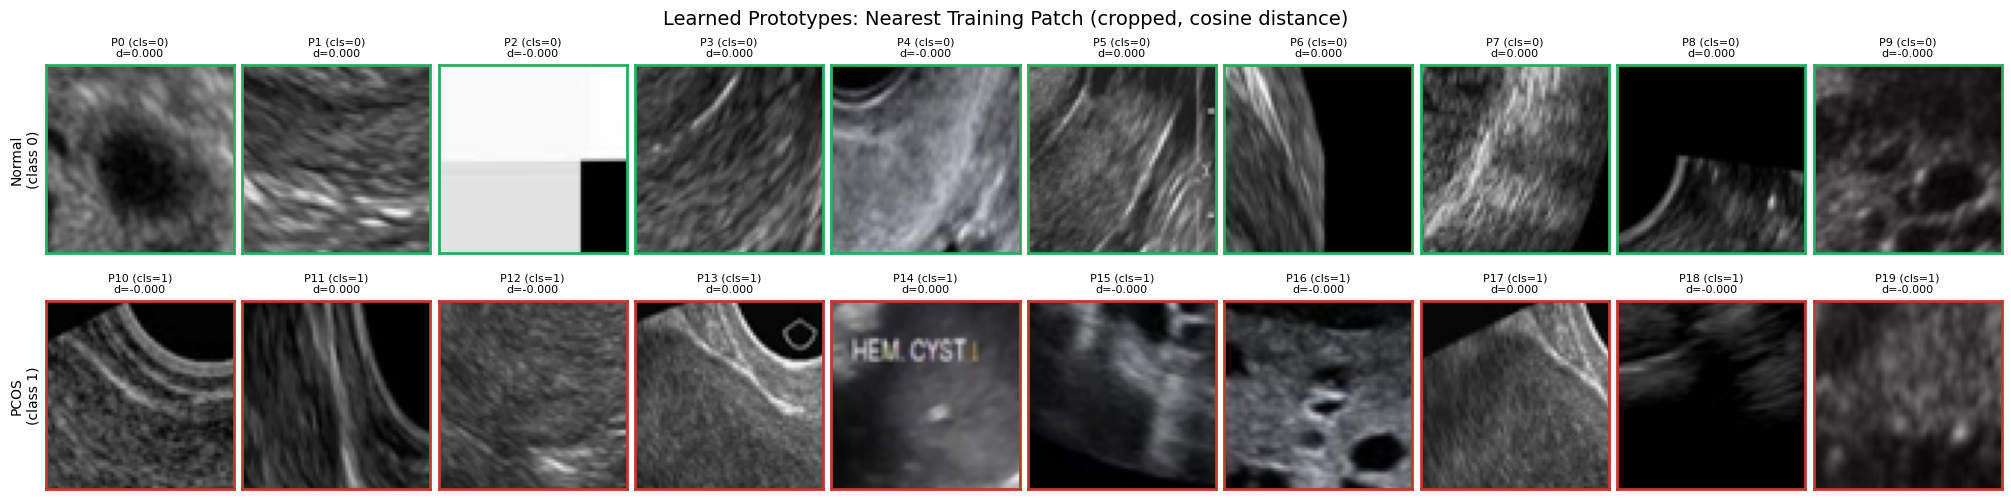

Saved prototype_gallery.png / .svg


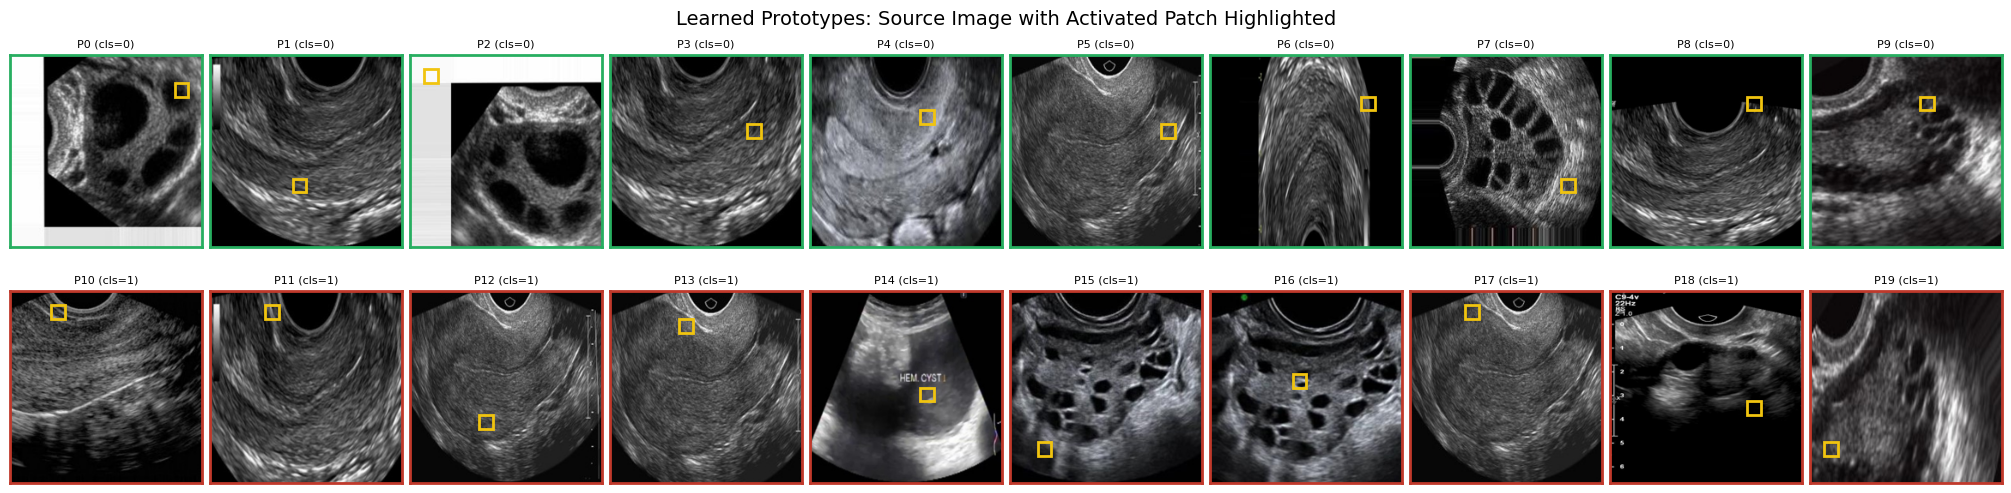

Saved prototype_gallery_fullimg.png

=== PROTOTYPE DIVERSITY REPORT ===
  Normal (class 0): 10/10 distinct | mean_cos=0.215 max_cos=0.723
  PCOS (class 1): 10/10 distinct | mean_cos=0.166 max_cos=0.918

Saved prototype_diversity.json


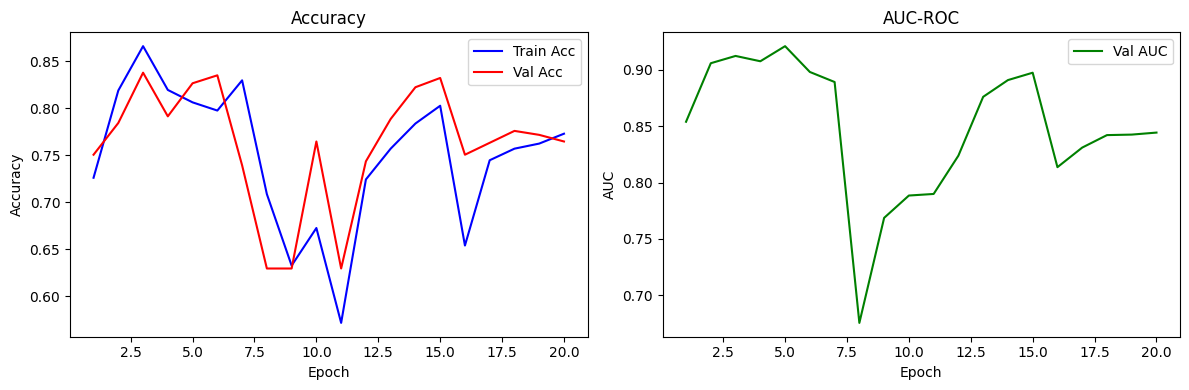

Saved training_curves.png


In [8]:
# ============================================================
# Cell 8: Prototype visualization (gallery) + diversity report
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcdefaults()
# matplotlib.rcParams['font.family'] = ['Liberation Sans', 'Arimo', 'DejaVu Sans']
matplotlib.rcParams['svg.fonttype'] = 'none'
import numpy as np
from PIL import Image

model.eval()
GRID = 14           # 14x14 patch grid for ViT-Base @ 224/16
PATCH_PX = 16       # each patch = 16x16 px in the 224x224 input
IMG_SIZE = 224

# Same normalization as PCOSDataset (needed to un-normalize for display)
MEAN = np.array([0.485, 0.456, 0.406]); STD = np.array([0.229, 0.224, 0.225])

# --- Step 1: for each prototype, find the single nearest training patch ---
# Track (image_path, patch_idx, cosine_distance). Cosine space matches the model.
proto_nearest = {}  # proto_idx -> dict(path, patch_idx, dist, label)
with torch.no_grad():
    protos_n = F.normalize(proto_layer.prototypes, dim=-1)  # (P, D)
    ptr = 0
    _fg_frac_sum = 0.0; _fg_n = 0; _zero_fg_imgs = 0   # MASK INSTRUMENTATION
    for images, labels in train_loader:
        bsz = images.shape[0]
        imgs = images.to(DEVICE)
        pf = model.get_patch_features(imgs)                  # (B, 196, D)
        pf_n = F.normalize(pf, dim=-1)
        # cosine distance = 2 - 2*cos ; shape (B, 196, P)
        sims = torch.matmul(pf_n, protos_n.t())
        dists = 2.0 - 2.0 * sims
        # Foreground mask: background patches (borders/banners) must not be shown
        # as prototype exemplars. Set their distance to +inf so min() skips them.
        fgm = compute_patch_mask(imgs)                       # (B, 196) bool
        _fg_frac_sum += fgm.float().mean(dim=1).sum().item(); _fg_n += bsz   # MASK INSTRUMENTATION
        _zero_fg_imgs += int((fgm.sum(dim=1) == 0).sum().item())             # MASK INSTRUMENTATION
        for b in range(bsz):
            sample = train_samples[ptr + b]
            fg_b = fgm[b]
            if fg_b.sum() == 0:                              # no tissue -> keep all
                fg_b = torch.ones_like(fg_b)
            for p in range(proto_layer.num_prototypes):
                d_bp = dists[b, :, p].clone()                # (196,)
                d_bp[~fg_b] = float('inf')                   # exclude background
                min_d, min_idx = d_bp.min(dim=0)
                md = min_d.item()
                if (p not in proto_nearest) or (md < proto_nearest[p]['dist']):
                    proto_nearest[p] = {'path': sample['path'],
                                        'patch_idx': int(min_idx.item()),
                                        'dist': md,
                                        'label': int(sample['label'])}
        ptr += bsz

# --- MASK INSTRUMENTATION: prove the tissue mask actually ran this session ---
_mean_fg = _fg_frac_sum / max(_fg_n, 1)
print(f"[MASK CHECK] mean foreground fraction per image = {_mean_fg:.3f} "
      f"({100*(1-_mean_fg):.1f}% of patches masked out as background/rim)")
print(f"[MASK CHECK] images with ZERO tissue patches (fell back to all-patches) = {_zero_fg_imgs}")
# For each learned prototype, confirm its chosen exemplar patch is a TISSUE patch.
_on_fg = 0
import numpy as _np
for _p, _info in proto_nearest.items():
    from PIL import Image
    _im = Image.open(_info['path'])          # PIL image at display size
    # recompute the mask on this single source image (ImageNet-normalized)
    _im3 = _im.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    _a3 = _np.asarray(_im3, dtype=_np.float32) / 255.0
    _mean_v = _np.array([0.485, 0.456, 0.406]); _std_v = _np.array([0.229, 0.224, 0.225])
    _a3n = (_a3 - _mean_v) / _std_v
    _x = torch.from_numpy(_a3n).permute(2, 0, 1)[None].float().to(DEVICE)
    _fg1 = compute_patch_mask(_x)[0]               # (196,)
    if _fg1.sum() == 0 or bool(_fg1[_info['patch_idx']].item()):
        _on_fg += 1
print(f"[MASK CHECK] prototypes landing on TISSUE patches = {_on_fg}/{len(proto_nearest)} "
      f"(expect all; a low number means the mask did NOT run)")
assert _mean_fg < 0.98, ("Tissue mask appears INACTIVE: >98%% of patches counted as "
                         "foreground. The v2 fan-erosion mask did not execute -- re-run "
                         "the model-definition cell (Restart & Run All).")

# --- Step 2: render gallery. For each prototype show the cropped activated patch
#     (with a little context) taken from the actual source image. ---
def load_display_img(path):
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    return np.asarray(img).astype(np.float32) / 255.0  # (224,224,3) in [0,1]

def crop_patch(disp_img, patch_idx, context=2, out_px=64):
    row, col = patch_idx // GRID, patch_idx % GRID
    y0 = max(0, (row - context) * PATCH_PX); y1 = min(IMG_SIZE, (row + 1 + context) * PATCH_PX)
    x0 = max(0, (col - context) * PATCH_PX); x1 = min(IMG_SIZE, (col + 1 + context) * PATCH_PX)
    crop = disp_img[y0:y1, x0:x1]
    # Resize every crop to a fixed square so all gallery cells render uniformly
    crop_img = Image.fromarray((np.clip(crop, 0, 1) * 255).astype(np.uint8)).resize((out_px, out_px))
    return np.asarray(crop_img).astype(np.float32) / 255.0, (row, col)

fig, axes = plt.subplots(2, 10, figsize=(20, 5.0), constrained_layout=True)
fig.suptitle('Learned Prototypes: Nearest Training Patch (cropped, cosine distance)', fontsize=14)
for c in range(2):
    for k in range(10):
        idx = c * 10 + k
        ax = axes[c, k]
        info = proto_nearest.get(idx)
        if info is not None:
            disp = load_display_img(info['path'])
            patch_crop, (row, col) = crop_patch(disp, info['patch_idx'])
            ax.imshow(patch_crop, aspect='equal')  # fixed square -> uniform cells
            ax.set_title(f"P{idx} (cls={c})\nd={info['dist']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#C0392B' if c == 1 else '#27AE60'); spine.set_linewidth(2)
axes[0, 0].set_ylabel('Normal\n(class 0)', fontsize=10)
axes[1, 0].set_ylabel('PCOS\n(class 1)', fontsize=10)
# NOTE: no tight_layout + no bbox_inches='tight' -> preserves the uniform grid
plt.savefig('/kaggle/working/prototype_gallery.png', dpi=150)
plt.savefig('/kaggle/working/prototype_gallery.svg')
plt.show()
print('Saved prototype_gallery.png / .svg')

# --- Step 3: full-image view with the activated patch highlighted (paper-quality) ---
fig, axes = plt.subplots(2, 10, figsize=(20, 5.0), constrained_layout=True)
fig.suptitle('Learned Prototypes: Source Image with Activated Patch Highlighted', fontsize=14)
for c in range(2):
    for k in range(10):
        idx = c * 10 + k
        ax = axes[c, k]
        info = proto_nearest.get(idx)
        if info is not None:
            disp = load_display_img(info['path'])
            ax.imshow(disp, aspect='equal')
            row, col = info['patch_idx'] // GRID, info['patch_idx'] % GRID
            rect = mpatches.Rectangle((col * PATCH_PX, row * PATCH_PX), PATCH_PX, PATCH_PX,
                                      linewidth=2, edgecolor='#F1C40F', facecolor='none')
            ax.add_patch(rect)
            ax.set_title(f"P{idx} (cls={c})", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#C0392B' if c == 1 else '#27AE60'); spine.set_linewidth(2)
plt.savefig('/kaggle/working/prototype_gallery_fullimg.png', dpi=150)
plt.show()
print('Saved prototype_gallery_fullimg.png')

# --- Step 4: prototype diversity report (quantitative XAI metric for the paper) ---
with torch.no_grad():
    pn = F.normalize(proto_layer.prototypes, dim=-1).cpu()
diversity_report = {}
print('\n=== PROTOTYPE DIVERSITY REPORT ===')
for c in range(2):
    s, e = c * 10, c * 10 + 10
    cos = (pn[s:e] @ pn[s:e].t()).numpy()
    off = cos[~np.eye(10, dtype=bool)]
    # effective distinct prototypes (cosine < 0.95 = not a duplicate)
    seen = set()
    for i in range(10):
        if i in seen: continue
        for j in range(i + 1, 10):
            if cos[i, j] > 0.95: seen.add(j)
    n_distinct = 10 - len(seen)
    diversity_report[f'class_{c}'] = {
        'n_distinct': int(n_distinct),
        'mean_pairwise_cos': float(off.mean()),
        'max_pairwise_cos': float(off.max()),
        'min_pairwise_cos': float(off.min()),
    }
    cls_name = 'PCOS' if c == 1 else 'Normal'
    print(f'  {cls_name} (class {c}): {n_distinct}/10 distinct | '
          f'mean_cos={off.mean():.3f} max_cos={off.max():.3f}')

# Prototype-to-distance summary (for supplementary table)
proto_dist_summary = {int(p): {'dist': round(proto_nearest[p]['dist'], 4),
                               'label': proto_nearest[p]['label'],
                               'patch_idx': proto_nearest[p]['patch_idx']}
                      for p in sorted(proto_nearest)}

# Persist diversity metrics alongside the checkpoint metrics
import json as _json
with open('/kaggle/working/prototype_diversity.json', 'w') as f:
    _json.dump({'diversity_report': diversity_report,
                'proto_nearest': proto_dist_summary}, f, indent=2)
print('\nSaved prototype_diversity.json')

# --- Also plot training curves (unchanged) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = [h['epoch'] for h in history]
ax1.plot(epochs, [h['train_acc'] for h in history], 'b-', label='Train Acc')
ax1.plot(epochs, [h['val_acc'] for h in history], 'r-', label='Val Acc')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.set_title('Accuracy')
ax2.plot(epochs, [h['val_auc'] for h in history], 'g-', label='Val AUC')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.legend(); ax2.set_title('AUC-ROC')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')
